In [2]:
import numpy as np
import pandas as pd

# Non-linear data
X = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([10, 25, 45, 60, 72, 80, 85, 88, 90, 91])

df = pd.DataFrame({
    'Hours': X,
    'Score': y
})

df

,Hours,Score
0,1,10
1,2,25
2,3,45
3,4,60
4,5,72
5,6,80
6,7,85
7,8,88
8,9,90
9,10,91


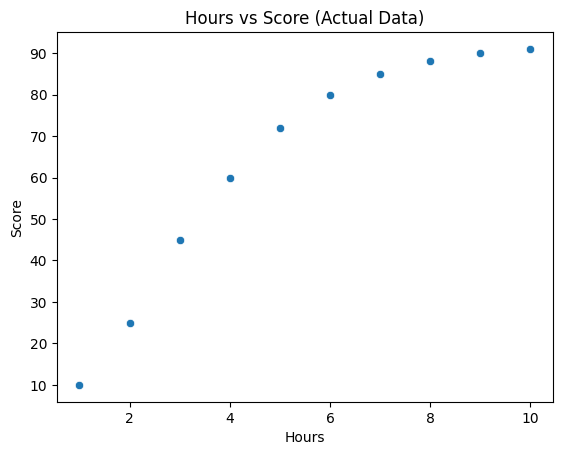

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='Hours', y='Score', data=df)
plt.title("Hours vs Score (Actual Data)")
plt.show()

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_feat = df[['Hours']]   # 2D
y_target = df['Score']   # 1D

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_target,
    test_size=0.2,
    random_state=42
)

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)  # Model Banaisi. But scaler use kori nai.

y_pred_lin = lin_model.predict(X_test)

In [11]:
from sklearn.metrics import mean_squared_error, r2_score

print("Linear MSE:", mean_squared_error(y_test, y_pred_lin))
print("Linear R2 :", r2_score(y_test, y_pred_lin))

Linear MSE: 81.05458531510108
Linear R2 : 0.9232619310626262


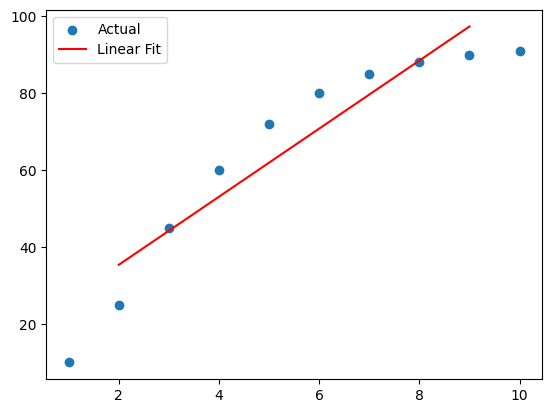

In [18]:
plt.scatter(X, y, label="Actual")
plt.plot(X_test, y_pred_lin, color='red', label="Linear Fit")
plt.legend()
plt.show()

In [19]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=True)

X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

In [20]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

In [21]:
print("Linear MSE:", mean_squared_error(y_test, y_pred_lin))
print("Linear R2 :", r2_score(y_test, y_pred_lin))
print("Polynomial MSE:", mean_squared_error(y_test, y_pred_poly))
print("Polynomial R2 :", r2_score(y_test, y_pred_poly))

Linear MSE: 81.05458531510108
Linear R2 : 0.9232619310626262
Polynomial MSE: 9.233481277208092
Polynomial R2 : 0.9912582425777912


C:\Users\Rezon\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


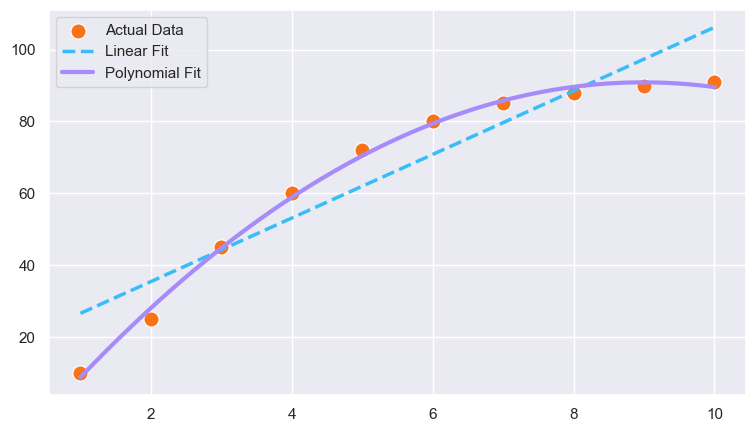

In [42]:
poly = PolynomialFeatures(degree=2, include_bias=True)
X_poly = poly.fit_transform(X.reshape(-1, 1))

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# Smooth curve
X_smooth = np.linspace(1, 10, 300).reshape(-1, 1)
y_poly_smooth = poly_model.predict(poly.transform(X_smooth))
y_lin_smooth  = lin_model.predict(X_smooth)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(x=X, y=y, ax=ax, color='#f97316', s=120, edgecolor='white', label='Actual Data')
ax.plot(X_smooth, y_lin_smooth,  '--', color='#38bdf8', lw=2.5, label='Linear Fit')
ax.plot(X_smooth, y_poly_smooth, '-',  color='#a78bfa', lw=3,   label='Polynomial Fit')
ax.legend()
plt.show()